## Import Libraries and GPU Setup

In [1]:
import copy
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True


Using device: mps


## Model Configuration


In [2]:
# Dataset and split configuration
DATA_PATH = "../../data/indoorAir2.csv"
RESAMPLE_FREQ = "15min"
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
MAX_FILL_STEPS = 2
STATION_COLUMN = "station_id"
SEGMENT_COLUMN = "_continuous_segment_id"

# Base sensor and calendar features
BASE_FEATURE_COLUMNS = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "is_weekend",
]

TARGET_FEATURE = "scd41_co2"
TARGET_LABELS = {
    "scd41_co2": "CO2",
    "ens160_aqi": "AQI",
    "ens160_tvoc": "TVOC",
    "bme688_gas_resistance": "Gas Resistance",
    "bme688_pressure": "Pressure",
    "scd41_temperature": "Temperature",
    "scd41_humidity": "Humidity",
}

def get_target_label(target_feature):
    return TARGET_LABELS.get(
        target_feature,
        target_feature.replace("_", " ").title()
    )

# Forecasting configuration: 24 hours history -> 6 hours forecast
SEQ_LENGTH = 96
OUTPUT_LENGTH = 24
BATCH_SIZE = 64
EPOCHS = 10
TRAIN_SEQUENCE_STRIDE = 2
EVAL_SEQUENCE_STRIDE = 4

# Wavelet scattering is now included in every model input window
USE_SCATTERING = True
SCATTERING_J = 4
SCATTERING_Q = 8
N_SCATTERING_FEATURES = 8

# Transformer configuration
D_MODEL = 128
NHEAD = 8
NUM_LAYERS = 3
DIM_FEEDFORWARD = 384
DROPOUT = 0.20
LOCAL_KERNEL_SIZE = 5

# Training configuration
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 5e-4
SCHEDULER_PATIENCE = 3
SCHEDULER_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-6
GRAD_CLIP_MAX_NORM = 1.0
HUBER_DELTA = 0.02
MSE_LOSS_WEIGHT = 0.50
DIFFERENCE_LOSS_WEIGHT = 0.35
CHANGE_WEIGHT_STRENGTH = 4.0
LAST_HORIZON_WEIGHT = 1.5
USE_EVENT_SAMPLER = True
EVENT_SAMPLING_STRENGTH = 1.5
MAX_SAMPLE_WEIGHT = 10.0

# Analysis and plotting configuration
PLOT_SIZE = 600
ATTENTION_NUM_SAMPLES = 64
MC_DROPOUT_RUNS = 30
ABLATION_FEATURE = TARGET_FEATURE
ABLATION_FEATURES = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
]

target_label = get_target_label(TARGET_FEATURE)


## Device Setup

## Load and Sort Dataset

In [3]:
df = pd.read_csv(DATA_PATH)

# Convert timestamp once
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

# Sort efficiently
df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)
df.head()


(1924653, 21)


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Station-aware Resampling and Dynamic Feature Engineering

Each station is resampled independently. Calendar features, recent CO2 change,
and short rolling CO2 statistics are calculated without using future values.


In [4]:
def add_time_and_change_features(data):
    data = data.copy()
    data["timestamp"] = pd.to_datetime(data["timestamp"])

    hour = data["timestamp"].dt.hour + data["timestamp"].dt.minute / 60
    dayofweek = data["timestamp"].dt.dayofweek

    data["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    data["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    data["dayofweek_sin"] = np.sin(2 * np.pi * dayofweek / 7)
    data["dayofweek_cos"] = np.cos(2 * np.pi * dayofweek / 7)
    data["is_weekend"] = dayofweek.isin([5, 6]).astype(float)

    grouped_target = data.groupby(STATION_COLUMN)[TARGET_FEATURE]
    data["co2_diff_1"] = grouped_target.diff()
    data["co2_rolling_mean_4"] = grouped_target.transform(
        lambda values: values.rolling(4, min_periods=1).mean()
    )
    data["co2_rolling_std_4"] = grouped_target.transform(
        lambda values: values.rolling(4, min_periods=2).std()
    )

    return data


sensor_columns = [
    column for column in BASE_FEATURE_COLUMNS
    if column not in {
        "hour_sin",
        "hour_cos",
        "dayofweek_sin",
        "dayofweek_cos",
        "is_weekend",
    }
]

feature_df = (
    df.set_index("timestamp")
    .groupby(STATION_COLUMN)[sensor_columns]
    .resample(RESAMPLE_FREQ)
    .mean()
    .reset_index()
)

feature_df = add_time_and_change_features(feature_df)

print("Feature Data Shape:", feature_df.shape)
feature_df.head()


Feature Data Shape: (186894, 17)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,co2_diff_1,co2_rolling_mean_4,co2_rolling_std_4
0,1,2024-11-13 16:45:00,1.0,35.000000,NaN,NaN,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0.0,NaN,483.333333,NaN
1,1,2024-11-13 17:00:00,1.0,26.857143,NaN,NaN,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0.0,-11.047619,477.809524,7.811846
2,1,2024-11-13 17:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.980785,-0.195090,0.974928,-0.222521,0.0,NaN,477.809524,7.811846
3,1,2024-11-13 17:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.991445,-0.130526,0.974928,-0.222521,0.0,NaN,477.809524,7.811846
4,1,2024-11-13 17:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.997859,-0.065403,0.974928,-0.222521,0.0,NaN,472.285714,NaN


## Chronological Train, Validation, and Test Split

Every station is split chronologically into 70% training, 15% validation, and
15% testing data. This prevents random future-to-past leakage while allowing
the model to learn station-specific behavior.


In [5]:
def temporal_split_by_station(data):
    train_parts = []
    val_parts = []
    test_parts = []

    for station_id, station_data in data.groupby(STATION_COLUMN, sort=True):
        station_data = station_data.sort_values("timestamp").reset_index(drop=True)
        row_count = len(station_data)
        train_end = int(row_count * TRAIN_RATIO)
        val_end = train_end + int(row_count * VAL_RATIO)

        train_part = station_data.iloc[:train_end].copy()
        val_part = station_data.iloc[train_end:val_end].copy()
        test_part = station_data.iloc[val_end:].copy()

        train_parts.append(train_part)
        val_parts.append(val_part)
        test_parts.append(test_part)

        print(f"\nStation {station_id}")
        print(
            "Train:",
            train_part["timestamp"].min(),
            "->",
            train_part["timestamp"].max(),
            train_part.shape,
        )
        print(
            "Validation:",
            val_part["timestamp"].min(),
            "->",
            val_part["timestamp"].max(),
            val_part.shape,
        )
        print(
            "Test:",
            test_part["timestamp"].min(),
            "->",
            test_part["timestamp"].max(),
            test_part.shape,
        )

    return (
        pd.concat(train_parts, ignore_index=True),
        pd.concat(val_parts, ignore_index=True),
        pd.concat(test_parts, ignore_index=True),
    )


train_df, val_df, test_df = temporal_split_by_station(feature_df)

print("\nTrain Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)



Station 1
Train: 2024-11-13 16:45:00 -> 2025-11-16 02:00:00 (35270, 17)
Validation: 2025-11-16 02:15:00 -> 2026-02-02 19:15:00 (7557, 17)
Test: 2026-02-02 19:30:00 -> 2026-04-22 13:00:00 (7559, 17)

Station 2
Train: 2024-12-20 12:30:00 -> 2025-05-10 20:00:00 (13567, 17)
Validation: 2025-05-10 20:15:00 -> 2025-06-10 02:45:00 (2907, 17)
Test: 2025-06-10 03:00:00 -> 2025-07-10 09:45:00 (2908, 17)

Station 3
Train: 2025-01-17 12:30:00 -> 2025-12-05 12:45:00 (30914, 17)
Validation: 2025-12-05 13:00:00 -> 2026-02-12 12:45:00 (6624, 17)
Test: 2026-02-12 13:00:00 -> 2026-04-22 13:00:00 (6625, 17)

Station 4
Train: 2025-01-21 18:30:00 -> 2025-12-06 19:15:00 (30628, 17)
Validation: 2025-12-06 19:30:00 -> 2026-02-13 04:00:00 (6563, 17)
Test: 2026-02-13 04:15:00 -> 2026-04-22 13:00:00 (6564, 17)

Station 5
Train: 2025-02-14 12:30:00 -> 2025-09-15 10:45:00 (20442, 17)
Validation: 2025-09-15 11:00:00 -> 2025-10-31 01:45:00 (4380, 17)
Test: 2025-10-31 02:00:00 -> 2025-12-15 17:00:00 (4381, 17)

Stat

## Short-Gap Filling and Long-Gap Segmentation

Only short feature gaps up to `MAX_FILL_STEPS` are filled. Missing CO2 targets
are never synthesized. Any remaining timestamp discontinuity starts a new
continuous segment, and forecast windows cannot cross that boundary.


In [6]:
def fill_short_feature_gaps(series, max_fill_steps):
    if max_fill_steps <= 0 or not series.isna().any():
        return series

    missing = series.isna()
    run_ids = missing.ne(missing.shift()).cumsum()
    run_lengths = missing.groupby(run_ids).transform("sum")
    short_gap_mask = missing & (run_lengths <= max_fill_steps)

    nearby_values = series.interpolate(limit_direction="both")
    filled = series.copy()
    filled.loc[short_gap_mask] = nearby_values.loc[short_gap_mask]
    return filled


def clean_and_segment(data):
    cleaned_parts = []
    expected_interval = pd.Timedelta(RESAMPLE_FREQ)

    excluded_columns = {
        "timestamp",
        STATION_COLUMN,
        SEGMENT_COLUMN,
        TARGET_FEATURE,
    }

    for station_id, station_data in data.groupby(STATION_COLUMN, sort=True):
        station_data = station_data.sort_values("timestamp").copy()
        feature_columns_to_fill = [
            column for column in station_data.columns
            if column not in excluded_columns
        ]

        before = int(station_data.isna().sum().sum())

        # Missing targets are never fabricated. Removing them creates a gap.
        station_data = station_data.dropna(subset=[TARGET_FEATURE])
        station_data[feature_columns_to_fill] = (
            station_data[feature_columns_to_fill]
            .apply(fill_short_feature_gaps, max_fill_steps=MAX_FILL_STEPS)
        )
        station_data = station_data.dropna()

        time_difference = station_data["timestamp"].diff()
        gap_mask = time_difference > expected_interval
        station_data[SEGMENT_COLUMN] = gap_mask.cumsum().astype(int)

        print(f"\nStation {station_id}")
        print("Missing values before cleaning:", before)
        print("Rows after limited filling:", len(station_data))
        print("Detected long gaps:", int(gap_mask.sum()))
        print("Continuous segments:", station_data[SEGMENT_COLUMN].nunique())
        print("Largest timestamp difference:", time_difference.max())

        cleaned_parts.append(station_data)

    if not cleaned_parts:
        raise ValueError("No rows remain after gap-aware cleaning.")

    return pd.concat(cleaned_parts, ignore_index=True)


train_df = clean_and_segment(train_df)
val_df = clean_and_segment(val_df)
test_df = clean_and_segment(test_df)



Station 1
Missing values before cleaning: 86637
Rows after limited filling: 24219
Detected long gaps: 20
Continuous segments: 21
Largest timestamp difference: 30 days 23:30:00

Station 2
Missing values before cleaning: 63087
Rows after limited filling: 7254
Detected long gaps: 6
Continuous segments: 7
Largest timestamp difference: 32 days 02:30:00

Station 3
Missing values before cleaning: 183572
Rows after limited filling: 12550
Detected long gaps: 15
Continuous segments: 16
Largest timestamp difference: 138 days 21:45:00

Station 4
Missing values before cleaning: 42491
Rows after limited filling: 26375
Detected long gaps: 17
Continuous segments: 18
Largest timestamp difference: 28 days 20:45:00

Station 5
Missing values before cleaning: 34850
Rows after limited filling: 16955
Detected long gaps: 8
Continuous segments: 9
Largest timestamp difference: 32 days 03:45:00

Station 6
Missing values before cleaning: 20
Rows after limited filling: 0
Detected long gaps: 0
Continuous segments:

## Station Identity and Model Features

Station one-hot features help the shared Transformer distinguish different
sensor environments. Recent CO2 differences and rolling statistics expose
local changes that a level-only input can hide.


In [7]:
station_ids = sorted(feature_df[STATION_COLUMN].unique().tolist())


def add_station_features(data):
    data = data.copy()
    for station_id in station_ids:
        data[f"station_{station_id}"] = (
            data[STATION_COLUMN] == station_id
        ).astype(float)
    return data


train_df = add_station_features(train_df)
val_df = add_station_features(val_df)
test_df = add_station_features(test_df)

station_feature_columns = [
    f"station_{station_id}" for station_id in station_ids
]

derived_feature_columns = [
    "co2_diff_1",
    "co2_rolling_mean_4",
    "co2_rolling_std_4",
]

feature_columns = (
    BASE_FEATURE_COLUMNS
    + derived_feature_columns
    + station_feature_columns
)

print("Dynamic model features:", len(feature_columns))
print(feature_columns)


Dynamic model features: 21
['ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend', 'co2_diff_1', 'co2_rolling_mean_4', 'co2_rolling_std_4', 'station_1', 'station_2', 'station_3', 'station_4', 'station_5', 'station_6']


## Training-Only Scaling

The scaler is fitted only on the training split, then applied unchanged to
validation and test data.


In [8]:
scaler = MinMaxScaler()
scaler.fit(train_df[feature_columns])


def scale_split(data):
    scaled = data.copy()
    scaled[feature_columns] = scaler.transform(data[feature_columns])
    return scaled


train_df = scale_split(train_df)
val_df = scale_split(val_df)
test_df = scale_split(test_df)

target_index = feature_columns.index(TARGET_FEATURE)
target_data_min = scaler.data_min_[target_index]
target_data_range = scaler.data_range_[target_index]

print("Scaler fitted only on training data.")
print("Target minimum:", target_data_min)
print("Target range:", target_data_range)


Scaler fitted only on training data.
Target minimum: 392.9
Target range: 3225.5166666666664


## Wavelet Scattering Configuration

Wavelet scattering coefficients are generated from each input window's CO2
history and appended to that window as model features.


In [9]:
from kymatio.scattering1d.frontend.numpy_frontend import ScatteringNumPy1D

scattering = None
scattering_feature_names = []

if USE_SCATTERING:
    scattering = ScatteringNumPy1D(
        J=SCATTERING_J,
        shape=SEQ_LENGTH,
        Q=SCATTERING_Q,
    )
    scattering_feature_names = [
        f"scatter_co2_{index + 1}"
        for index in range(N_SCATTERING_FEATURES)
    ]

print("Use scattering:", USE_SCATTERING)
print("Scattering feature count:", len(scattering_feature_names))


Use scattering: True
Scattering feature count: 8


/Users/nidhimandaviya/Desktop/DM/anaconda3/envs/torch-env/lib/python3.11/site-packages/kymatio/scattering1d/filter_bank.py:218: UserWarning: Signal support is too small to avoid border effects
  warnings.warn('Signal support is too small to avoid border effects')


In [10]:
target_label = get_target_label(TARGET_FEATURE)
target_index = feature_columns.index(TARGET_FEATURE)

print("Target Feature:", TARGET_FEATURE)
print("Target Label  :", target_label)
print("Target Index  :", target_index)
print("Input Length  :", SEQ_LENGTH)
print("Output Length :", OUTPUT_LENGTH)
print("Maximum filled gap:", pd.Timedelta(RESAMPLE_FREQ) * MAX_FILL_STEPS)
print("Sequences crossing station or long-gap boundaries: disabled")


Target Feature: scd41_co2
Target Label  : CO2
Target Index  : 6
Input Length  : 96
Output Length : 24
Maximum filled gap: 0 days 00:30:00
Sequences crossing station or long-gap boundaries: disabled


## Initialize Per-Window Wavelet Scattering

The transform is configured once and reused during sequence generation.


In [11]:
def compute_scattering_vector(signal_window):
    coefficients = np.asarray(
        scattering(np.asarray(signal_window, dtype=np.float32))
    )

    if coefficients.ndim == 2:
        vector = coefficients.mean(axis=1)
    else:
        vector = coefficients.reshape(-1)

    vector = vector[:N_SCATTERING_FEATURES]
    if len(vector) < N_SCATTERING_FEATURES:
        vector = np.pad(
            vector,
            (0, N_SCATTERING_FEATURES - len(vector)),
            mode="constant",
        )

    return vector.astype(np.float32)


print("Scattering transform ready.")


Scattering transform ready.


## Verify Wavelet Scattering

A continuous training segment is used to confirm the configured input length
and scattering feature dimensions before all sequences are generated.


In [12]:
sample_segment = next(
    segment
    for _, segment in train_df.groupby(
        [STATION_COLUMN, SEGMENT_COLUMN],
        sort=True,
    )
    if len(segment) >= SEQ_LENGTH
)

sample_signal = sample_segment[TARGET_FEATURE].values[:SEQ_LENGTH]
print("Signal Shape:", sample_signal.shape)


Signal Shape: (96,)


In [13]:
if USE_SCATTERING and len(sample_signal) == SEQ_LENGTH:
    sample_scattering = compute_scattering_vector(sample_signal)
    print("Scattering vector shape:", sample_scattering.shape)
    print(sample_scattering)
else:
    print("Sample segment is too short or scattering is disabled.")


Scattering vector shape: (8,)
[0.07630901 0.00036578 0.00043021 0.00032546 0.00023532 0.00047104
 0.0006175  0.0006087 ]


## Wavelet Features Used by the Model

Unlike the previous notebook, scattering is not a demonstration-only step.
Each sequence receives its own compact scattering vector.


In [14]:
print(
    "Wavelet coefficients are computed separately for every input window "
    "inside sequence generation. They are no longer demonstration-only."
)


Wavelet coefficients are computed separately for every input window inside sequence generation. They are no longer demonstration-only.


## Final Feature Set

The model receives sensor, calendar, recent-change, station identity, and
wavelet-scattering features.


In [15]:
final_feature_columns = feature_columns + scattering_feature_names
print("Final model feature count:", len(final_feature_columns))
print(final_feature_columns)


Final model feature count: 29
['ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend', 'co2_diff_1', 'co2_rolling_mean_4', 'co2_rolling_std_4', 'station_1', 'station_2', 'station_3', 'station_4', 'station_5', 'station_6', 'scatter_co2_1', 'scatter_co2_2', 'scatter_co2_3', 'scatter_co2_4', 'scatter_co2_5', 'scatter_co2_6', 'scatter_co2_7', 'scatter_co2_8']


In [16]:
print(train_df.columns.tolist())


['station_id', 'timestamp', 'ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend', 'co2_diff_1', 'co2_rolling_mean_4', 'co2_rolling_std_4', '_continuous_segment_id', 'station_1', 'station_2', 'station_3', 'station_4', 'station_5', 'station_6']


# Gap-Aware Sequence Generation

Input/output windows are created separately inside each station and continuous
segment. Configurable strides reduce highly overlapping duplicate samples.


In [17]:
def create_sequences(data, split_name, sequence_stride):
    inputs = []
    targets = []
    metadata = []
    required_length = SEQ_LENGTH + OUTPUT_LENGTH

    grouped_segments = data.groupby(
        [STATION_COLUMN, SEGMENT_COLUMN],
        sort=True,
    )

    for (station_id, segment_id), segment in grouped_segments:
        segment = segment.sort_values("timestamp")
        values = segment[feature_columns].to_numpy(dtype=np.float32)
        timestamps = segment["timestamp"].to_numpy()

        if len(segment) <= required_length:
            print(
                f"Skipping {split_name} station={station_id}, "
                f"segment={segment_id}: {len(segment)} rows"
            )
            continue

        for start in range(
            0,
            len(segment) - required_length + 1,
            sequence_stride,
        ):
            input_window = values[start:start + SEQ_LENGTH].copy()
            target_window = values[
                start + SEQ_LENGTH:
                start + required_length,
                target_index,
            ]

            if USE_SCATTERING:
                scattering_vector = compute_scattering_vector(
                    input_window[:, target_index]
                )
                repeated_scattering = np.repeat(
                    scattering_vector.reshape(1, -1),
                    SEQ_LENGTH,
                    axis=0,
                )
                input_window = np.concatenate(
                    [input_window, repeated_scattering],
                    axis=1,
                )

            inputs.append(input_window)
            targets.append(target_window)
            metadata.append(
                {
                    "station_id": station_id,
                    "segment_id": segment_id,
                    "input_start": timestamps[start],
                    "forecast_start": timestamps[start + SEQ_LENGTH],
                }
            )

    if not inputs:
        raise ValueError(f"No sequences created for {split_name}.")

    X = np.asarray(inputs, dtype=np.float32)
    y = np.asarray(targets, dtype=np.float32)
    metadata = pd.DataFrame(metadata)

    print(f"{split_name} input shape:", X.shape)
    print(f"{split_name} target shape:", y.shape)
    print(f"{split_name} metadata shape:", metadata.shape)
    return X, y, metadata


In [18]:
X_train, y_train, train_metadata = create_sequences(
    train_df,
    "Train",
    TRAIN_SEQUENCE_STRIDE,
)
X_val, y_val, val_metadata = create_sequences(
    val_df,
    "Validation",
    EVAL_SEQUENCE_STRIDE,
)
X_test, y_test, test_metadata = create_sequences(
    test_df,
    "Test",
    EVAL_SEQUENCE_STRIDE,
)

print("Sequences are grouped by station and continuous segment.")
print("Training sequence stride:", TRAIN_SEQUENCE_STRIDE)
print("Validation/test sequence stride:", EVAL_SEQUENCE_STRIDE)


Skipping Train station=1, segment=0: 2 rows
Skipping Train station=1, segment=1: 2 rows
Skipping Train station=1, segment=7: 15 rows
Skipping Train station=1, segment=10: 1 rows
Skipping Train station=1, segment=11: 39 rows
Skipping Train station=1, segment=12: 27 rows
Skipping Train station=1, segment=13: 4 rows
Skipping Train station=1, segment=14: 16 rows
Skipping Train station=1, segment=15: 3 rows
Skipping Train station=1, segment=16: 2 rows
Skipping Train station=1, segment=17: 6 rows
Skipping Train station=1, segment=18: 1 rows
Skipping Train station=2, segment=0: 2 rows
Skipping Train station=2, segment=1: 1 rows
Skipping Train station=2, segment=2: 2 rows
Skipping Train station=2, segment=3: 1 rows
Skipping Train station=2, segment=4: 30 rows
Skipping Train station=3, segment=0: 1 rows
Skipping Train station=3, segment=6: 1 rows
Skipping Train station=3, segment=8: 11 rows
Skipping Train station=3, segment=9: 1 rows
Skipping Train station=3, segment=10: 51 rows
Skipping Train 

## Create DataLoaders

In [19]:
def create_loader(X, y, shuffle=False, sampler=None):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle if sampler is None else False,
        sampler=sampler,
        num_workers=0,
    )


train_sampler = None

if USE_EVENT_SAMPLER:
    last_train_target = X_train[:, -1, target_index]
    future_change = np.max(
        np.abs(y_train - last_train_target[:, None]),
        axis=1,
    )
    change_scale = max(np.quantile(future_change, 0.90), 1e-6)
    event_weights = 1.0 + EVENT_SAMPLING_STRENGTH * np.clip(
        future_change / change_scale,
        0.0,
        3.0,
    )

    station_counts = train_metadata["station_id"].value_counts()
    station_weights = train_metadata["station_id"].map(
        lambda station: np.sqrt(len(train_metadata) / station_counts[station])
    ).to_numpy()

    sample_weights = np.clip(
        event_weights * station_weights,
        1.0,
        MAX_SAMPLE_WEIGHT,
    )
    train_sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

    print("Event sampler enabled")
    print("90th percentile future change:", change_scale)
    print("Sample weight range:", sample_weights.min(), sample_weights.max())

train_loader = create_loader(
    X_train,
    y_train,
    sampler=train_sampler,
)
val_loader = create_loader(X_val, y_val, shuffle=False)
test_loader = create_loader(X_test, y_test, shuffle=False)

sample_X, sample_y = next(iter(train_loader))
print("Batch input shape :", sample_X.shape)
print("Batch target shape:", sample_y.shape)


Event sampler enabled
90th percentile future change: 0.10421069
Sample weight range: 1.85220922258537 10.0
Batch input shape : torch.Size([64, 96, 29])
Batch target shape: torch.Size([64, 24])


## Positional Encoding


In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


## Local-Pattern Transformer with Horizon Queries

A depthwise temporal convolution first captures short local behavior. The
Transformer encoder models longer dependencies, and one learned query per
forecast horizon produces distinct 24-step predictions. Forecasts are learned
as residual changes from the latest observed CO2 value.


In [21]:
class TransformerModel(nn.Module):
    def __init__(
        self,
        input_dim,
        target_index,
        output_length,
        d_model,
        nhead,
        num_layers,
        dim_feedforward,
        dropout,
        local_kernel_size,
    ):
        super().__init__()
        self.target_index = target_index
        self.output_length = output_length

        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
        )

        self.local_conv = nn.Sequential(
            nn.Conv1d(
                d_model,
                d_model,
                kernel_size=local_kernel_size,
                padding=local_kernel_size // 2,
                groups=d_model,
            ),
            nn.Conv1d(d_model, d_model, kernel_size=1),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.positional_encoding = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model),
        )

        self.horizon_queries = nn.Parameter(
            torch.randn(output_length, d_model) * 0.02
        )
        self.horizon_attention = nn.MultiheadAttention(
            d_model,
            nhead,
            dropout=dropout,
            batch_first=True,
        )
        self.forecast_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def encode(self, x):
        projected = self.input_projection(x)
        local_features = self.local_conv(
            projected.transpose(1, 2)
        ).transpose(1, 2)
        encoded_input = self.positional_encoding(
            projected + local_features
        )
        return self.transformer_encoder(encoded_input)

    def forward(self, x):
        last_target = x[:, -1, self.target_index]
        encoded = self.encode(x)

        queries = self.horizon_queries.unsqueeze(0).expand(
            x.size(0),
            -1,
            -1,
        )
        decoded, _ = self.horizon_attention(
            queries,
            encoded,
            encoded,
            need_weights=False,
        )

        forecast_delta = self.forecast_head(decoded).squeeze(-1)
        return last_target.unsqueeze(1) + forecast_delta


## Initialize Transformer Model

In [22]:
model = TransformerModel(
    input_dim=len(final_feature_columns),
    target_index=target_index,
    output_length=OUTPUT_LENGTH,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    local_kernel_size=LOCAL_KERNEL_SIZE,
).to(device)

sample_X = sample_X.to(device)
with torch.no_grad():
    sample_prediction = model(sample_X)

print(model)
print("Sanity-check prediction shape:", sample_prediction.shape)


TransformerModel(
  (input_projection): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (local_conv): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), groups=128)
    (1): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=384, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=384, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
 

/var/folders/nc/_n9llygx3hg288c16cktsx180000gn/T/ipykernel_18613/998470435.py:47: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(


## Pattern-Aware Loss, Optimizer, and Scheduler

The loss combines weighted level accuracy with first-difference accuracy so
the model is penalized for flat or incorrectly shaped forecasts.


In [23]:
class PatternAwareForecastLoss(nn.Module):
    def __init__(
        self,
        huber_delta,
        mse_weight,
        difference_weight,
        change_weight_strength,
        output_length,
        last_horizon_weight,
    ):
        super().__init__()
        self.value_loss = nn.HuberLoss(
            delta=huber_delta,
            reduction="none",
        )
        self.mse_weight = mse_weight
        self.difference_weight = difference_weight
        self.change_weight_strength = change_weight_strength
        self.register_buffer(
            "horizon_weights",
            torch.linspace(1.0, last_horizon_weight, output_length),
        )

    def forward(self, predictions, targets, last_observed):
        future_change = torch.abs(targets - last_observed.unsqueeze(1))
        change_weights = 1.0 + self.change_weight_strength * future_change
        combined_weights = change_weights * self.horizon_weights.unsqueeze(0)
        level_loss = (
            self.value_loss(predictions, targets) * combined_weights
        ).mean()
        mse_loss = (
            (predictions - targets).pow(2) * combined_weights
        ).mean()

        previous_prediction = torch.cat(
            [last_observed.unsqueeze(1), predictions[:, :-1]],
            dim=1,
        )
        previous_target = torch.cat(
            [last_observed.unsqueeze(1), targets[:, :-1]],
            dim=1,
        )
        predicted_difference = predictions - previous_prediction
        target_difference = targets - previous_target
        difference_loss = self.value_loss(
            predicted_difference,
            target_difference,
        ).mean()

        return (
            level_loss
            + self.mse_weight * mse_loss
            + self.difference_weight * difference_loss
        )


criterion = PatternAwareForecastLoss(
    huber_delta=HUBER_DELTA,
    mse_weight=MSE_LOSS_WEIGHT,
    difference_weight=DIFFERENCE_LOSS_WEIGHT,
    change_weight_strength=CHANGE_WEIGHT_STRENGTH,
    output_length=OUTPUT_LENGTH,
    last_horizon_weight=LAST_HORIZON_WEIGHT,
).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=SCHEDULER_PATIENCE,
    factor=SCHEDULER_FACTOR,
    min_lr=MIN_LEARNING_RATE,
)

print("Base robust loss: nn.HuberLoss")
print("Combined loss: Huber + weighted MSE + temporal difference")
print("Optimizer: AdamW")
print("Initial learning rate:", LEARNING_RATE)
print("Epoch limit:", EPOCHS)


Base robust loss: nn.HuberLoss
Combined loss: Huber + weighted MSE + temporal difference
Optimizer: AdamW
Initial learning rate: 0.0002
Epoch limit: 10


In [24]:
print("Training device:", device)


Training device: mps


## Fixed 10-Epoch Training with Validation Checkpointing

Training always runs all 10 epochs. It uses gradient clipping, adaptive
learning-rate reduction, and restoration of the best validation checkpoint.


In [25]:
def evaluate_loader_loss(model, loader):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            last_observed = X_batch[:, -1, target_index]
            total_loss += criterion(
                predictions,
                y_batch,
                last_observed,
            ).item()

    return total_loss / len(loader)


train_losses = []
val_losses = []
learning_rates = []
best_val_loss = float("inf")
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        predictions = model(X_batch)
        last_observed = X_batch[:, -1, target_index]
        loss = criterion(predictions, y_batch, last_observed)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=GRAD_CLIP_MAX_NORM,
        )
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = evaluate_loader_loss(model, val_loader)
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    learning_rates.append(current_lr)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train: {avg_train_loss:.6f} | "
        f"Validation: {avg_val_loss:.6f} | "
        f"LR: {current_lr:.7f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("Best validation loss:", best_val_loss)
print("Best validation checkpoint restored.")


Epoch [1/10] | Train: 0.013244 | Validation: 0.007470 | LR: 0.0002000
Epoch [2/10] | Train: 0.008396 | Validation: 0.007373 | LR: 0.0002000
Epoch [3/10] | Train: 0.007316 | Validation: 0.007047 | LR: 0.0002000
Epoch [4/10] | Train: 0.006623 | Validation: 0.006338 | LR: 0.0002000
Epoch [5/10] | Train: 0.005930 | Validation: 0.006525 | LR: 0.0002000
Epoch [6/10] | Train: 0.005384 | Validation: 0.006929 | LR: 0.0002000
Epoch [7/10] | Train: 0.004554 | Validation: 0.006614 | LR: 0.0002000
Epoch [8/10] | Train: 0.004275 | Validation: 0.006814 | LR: 0.0001000
Epoch [9/10] | Train: 0.003683 | Validation: 0.007038 | LR: 0.0001000
Epoch [10/10] | Train: 0.003444 | Validation: 0.007230 | LR: 0.0001000
Best validation loss: 0.006337844072164872
Best validation checkpoint restored.


## Model Evaluation

In [26]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(device))
        predictions.append(outputs.cpu().numpy())
        actuals.append(y_batch.numpy())

predictions = np.vstack(predictions)
actual = np.vstack(actuals)


def inverse_target_scale(values):
    return values * target_data_range + target_data_min


predictions_original = inverse_target_scale(predictions)
actual_original = inverse_target_scale(actual)
persistence_scaled = np.repeat(
    X_test[:, -1, target_index][:, None],
    OUTPUT_LENGTH,
    axis=1,
)
persistence_original = inverse_target_scale(persistence_scaled)

mse = mean_squared_error(
    actual_original.flatten(),
    predictions_original.flatten(),
)
rmse = np.sqrt(mse)
mae = mean_absolute_error(
    actual_original.flatten(),
    predictions_original.flatten(),
)
r2 = r2_score(
    actual_original.flatten(),
    predictions_original.flatten(),
)

normalized_mse = mean_squared_error(actual.flatten(), predictions.flatten())
normalized_rmse = np.sqrt(normalized_mse)
normalized_mae = mean_absolute_error(actual.flatten(), predictions.flatten())

persistence_mse = mean_squared_error(
    actual_original.flatten(),
    persistence_original.flatten(),
)
persistence_rmse = np.sqrt(persistence_mse)
persistence_mae = mean_absolute_error(
    actual_original.flatten(),
    persistence_original.flatten(),
)
persistence_r2 = r2_score(
    actual_original.flatten(),
    persistence_original.flatten(),
)
rmse_skill = 1.0 - rmse / persistence_rmse

print("\nGap-aware Wavelet Transformer Metrics in Original CO2 Units\n")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R2   : {r2:.6f}")

print("\nNormalized-scale metrics for older notebook comparison")
print(f"MSE  : {normalized_mse:.6f}")
print(f"RMSE : {normalized_rmse:.6f}")
print(f"MAE  : {normalized_mae:.6f}")

print("\nPersistence baseline in original CO2 units")
print(f"RMSE : {persistence_rmse:.6f}")
print(f"MAE  : {persistence_mae:.6f}")
print(f"R2   : {persistence_r2:.6f}")
print(f"RMSE skill over persistence: {rmse_skill:.2%}")

absolute_errors = np.abs(actual_original - predictions_original)
print("\nAbsolute error percentiles (ppm)")
for percentile in [50, 75, 90, 95, 99]:
    print(
        f"P{percentile}: "
        f"{np.percentile(absolute_errors, percentile):.3f}"
    )

station_metric_rows = []
for station_id in sorted(test_metadata["station_id"].unique()):
    station_mask = test_metadata["station_id"].to_numpy() == station_id
    station_actual = actual_original[station_mask]
    station_prediction = predictions_original[station_mask]
    station_metric_rows.append(
        {
            "Station": station_id,
            "Samples": int(station_mask.sum()),
            "RMSE": np.sqrt(
                mean_squared_error(
                    station_actual.flatten(),
                    station_prediction.flatten(),
                )
            ),
            "MAE": mean_absolute_error(
                station_actual.flatten(),
                station_prediction.flatten(),
            ),
        }
    )

station_metrics_df = pd.DataFrame(station_metric_rows)
display(station_metrics_df)



Gap-aware Wavelet Transformer Metrics in Original CO2 Units

MSE  : 21178.236101
RMSE : 145.527441
MAE  : 60.622946
R2   : -0.280445

Normalized-scale metrics for older notebook comparison
MSE  : 0.002036
RMSE : 0.045118
MAE  : 0.018795

Persistence baseline in original CO2 units
RMSE : 108.931836
MAE  : 25.548296
R2   : 0.282568
RMSE skill over persistence: -33.59%

Absolute error percentiles (ppm)
P50: 28.166
P75: 46.446
P90: 95.962
P95: 228.989
P99: 743.548


,Station,Samples,RMSE,MAE
0,1,1762,32.069099,24.083353
1,2,620,54.435936,38.652096
2,3,1528,175.243275,73.297801
3,4,1513,206.111296,99.378736


## Actual vs Predicted Visualization

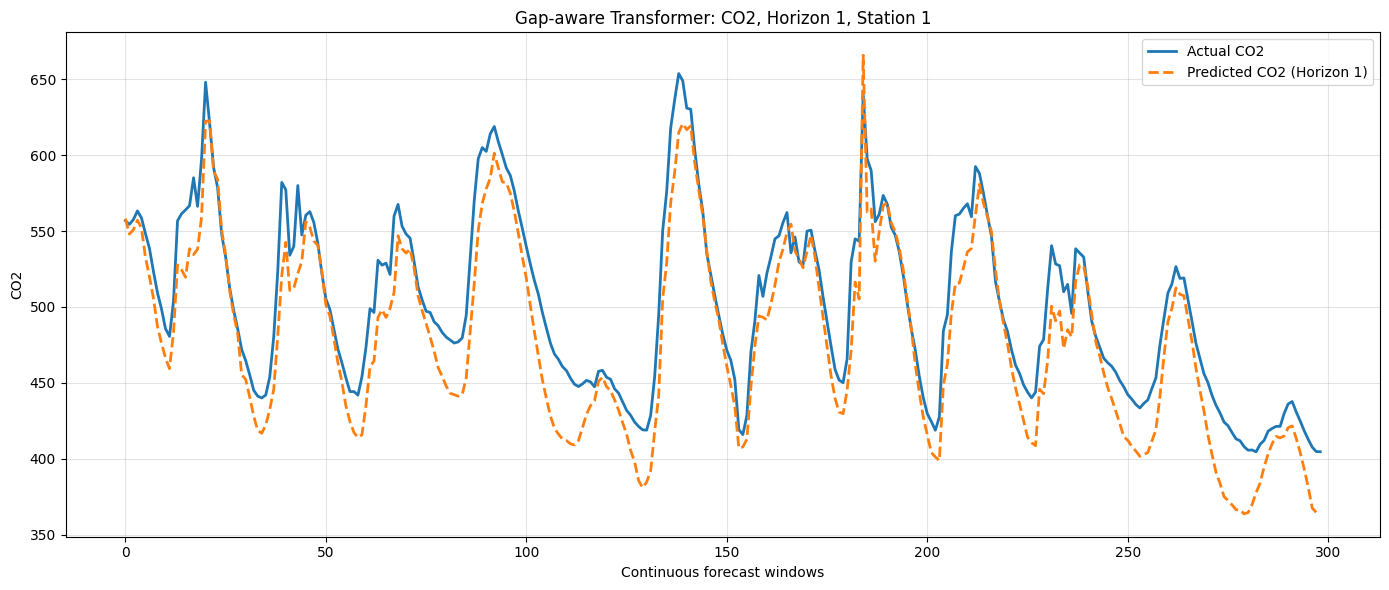

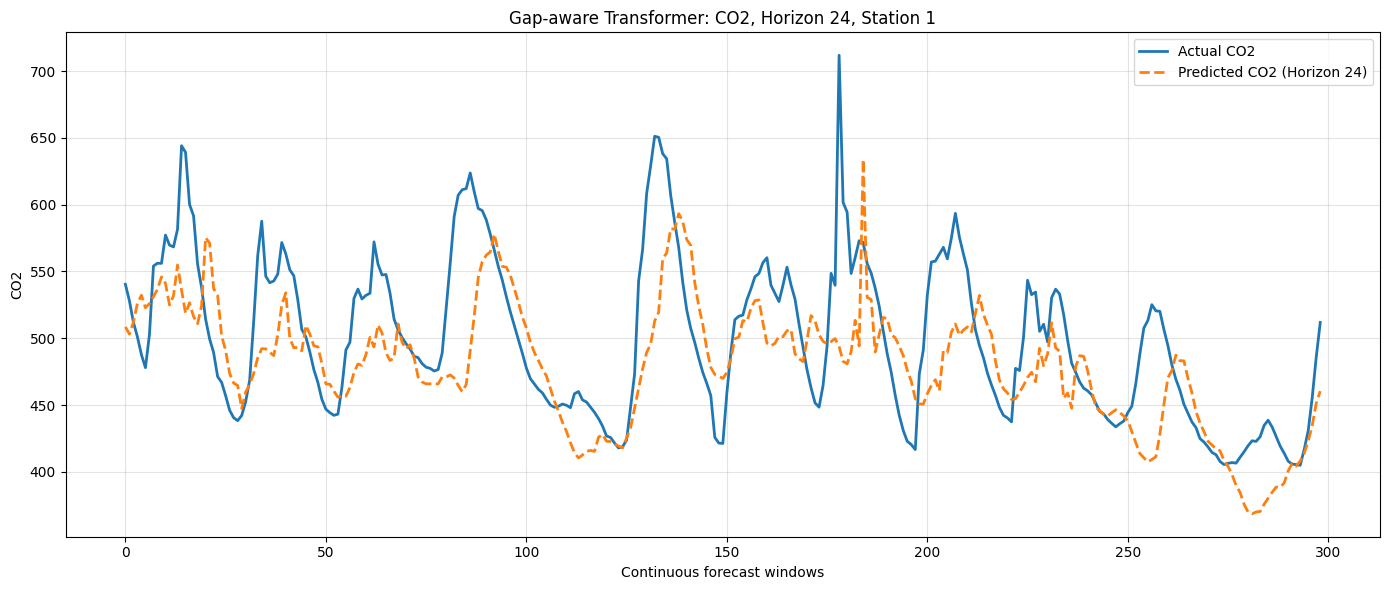

In [27]:
plot_metadata = test_metadata.copy()
first_station = plot_metadata.iloc[0]["station_id"]
first_segment = plot_metadata.iloc[0]["segment_id"]
continuous_mask = (
    (plot_metadata["station_id"] == first_station)
    & (plot_metadata["segment_id"] == first_segment)
)
continuous_indices = np.flatnonzero(continuous_mask.to_numpy())
continuous_indices = continuous_indices[:PLOT_SIZE]

for horizon_to_compare in [1, OUTPUT_LENGTH]:
    horizon_index = horizon_to_compare - 1

    plt.figure(figsize=(14, 6))
    plt.plot(
        actual_original[continuous_indices, horizon_index],
        label=f"Actual {target_label}",
        linewidth=2,
    )
    plt.plot(
        predictions_original[continuous_indices, horizon_index],
        label=f"Predicted {target_label} (Horizon {horizon_to_compare})",
        linewidth=2,
        linestyle="--",
    )

    plt.title(
        f"Gap-aware Transformer: {target_label}, "
        f"Horizon {horizon_to_compare}, Station {first_station}"
    )
    plt.xlabel("Continuous forecast windows")
    plt.ylabel(target_label)
    plt.legend()
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()


## Training and Validation Loss Visualization

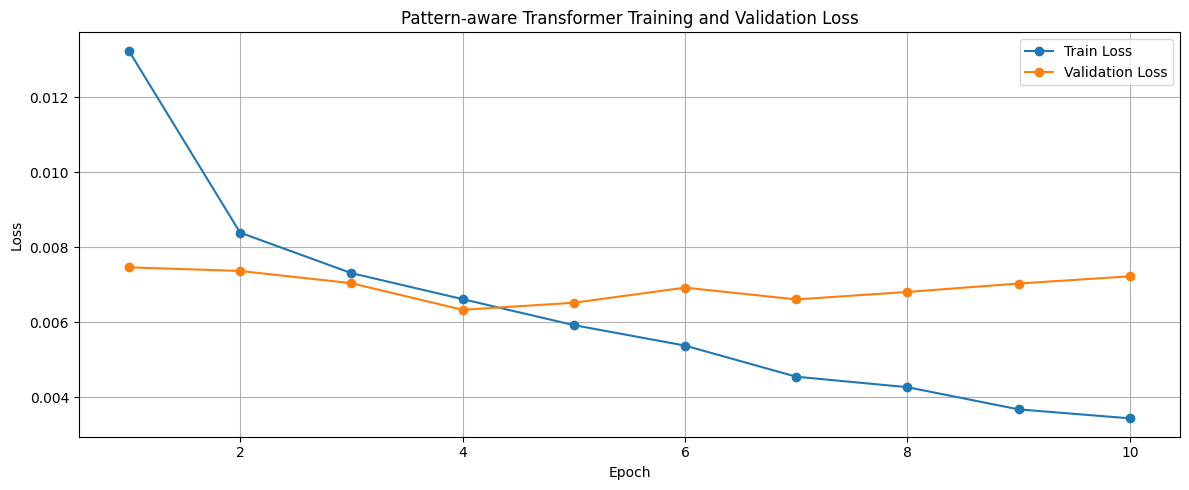

In [28]:
completed_epochs = len(train_losses)
plt.figure(figsize=(12, 5))
plt.plot(
    range(1, completed_epochs + 1),
    train_losses,
    marker="o",
    label="Train Loss",
)
plt.plot(
    range(1, completed_epochs + 1),
    val_losses,
    marker="o",
    label="Validation Loss",
)
plt.title("Pattern-aware Transformer Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
MODEL_PATH = (
    f"wavelet_transformer_IL{SEQ_LENGTH}_OL{OUTPUT_LENGTH}_"
    f"DM{D_MODEL}_L{NUM_LAYERS}.pth"
)
torch.save(model.state_dict(), MODEL_PATH)
print("Model saved:", MODEL_PATH)


Model saved: wavelet_transformer_IL96_OL24_DM128_L3.pth


# Explainability Analysis

## Technique 1: Attention Weight Analysis

In [30]:
print(model)

for name, module in model.named_modules():
    if isinstance(module, nn.MultiheadAttention):
        print("\nFound MultiheadAttention Layer:")
        print(name)


TransformerModel(
  (input_projection): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (local_conv): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), groups=128)
    (1): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=384, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=384, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
 

### Step 1: Attention Weight Extraction Verification

In [31]:
num_samples = min(ATTENTION_NUM_SAMPLES, len(X_test))
sample_batch = torch.tensor(
    X_test[:num_samples],
    dtype=torch.float32,
    device=device,
)

with torch.no_grad():
    projected = model.input_projection(sample_batch)
    local_features = model.local_conv(
        projected.transpose(1, 2)
    ).transpose(1, 2)
    encoder_input = model.positional_encoding(
        projected + local_features
    )

    attention_output, attention_weights = (
        model.transformer_encoder.layers[0].self_attn(
            encoder_input,
            encoder_input,
            encoder_input,
            need_weights=True,
            average_attn_weights=False,
        )
    )

print("Attention output shape:", attention_output.shape)
print("Attention weights shape:", attention_weights.shape)


Attention output shape: torch.Size([64, 96, 128])
Attention weights shape: torch.Size([64, 8, 96, 96])


### Step 2: Attention Heatmap Visualization

Attention Matrix Shape: (96, 96)


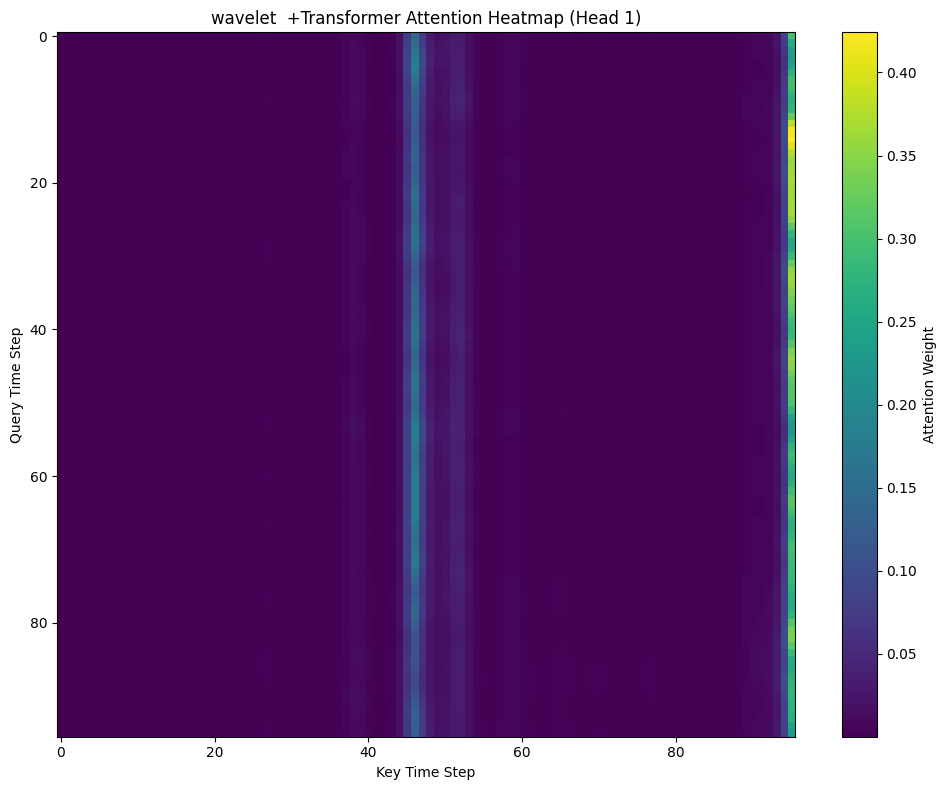

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Select first sample
attention_matrix = (
    attention_weights[0, 0]  # Sample 0, Head 0
    .cpu()
    .numpy()
)

print("Attention Matrix Shape:", attention_matrix.shape)

plt.figure(figsize=(10, 8))

plt.imshow(
    attention_matrix,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Attention Weight")

plt.title(
    "wavelet  +Transformer Attention Heatmap (Head 1)"
)

plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")

plt.tight_layout()
plt.show()


### Step 3: Average Multi-Head Attention Analysis

Average Attention Shape: (96, 96)


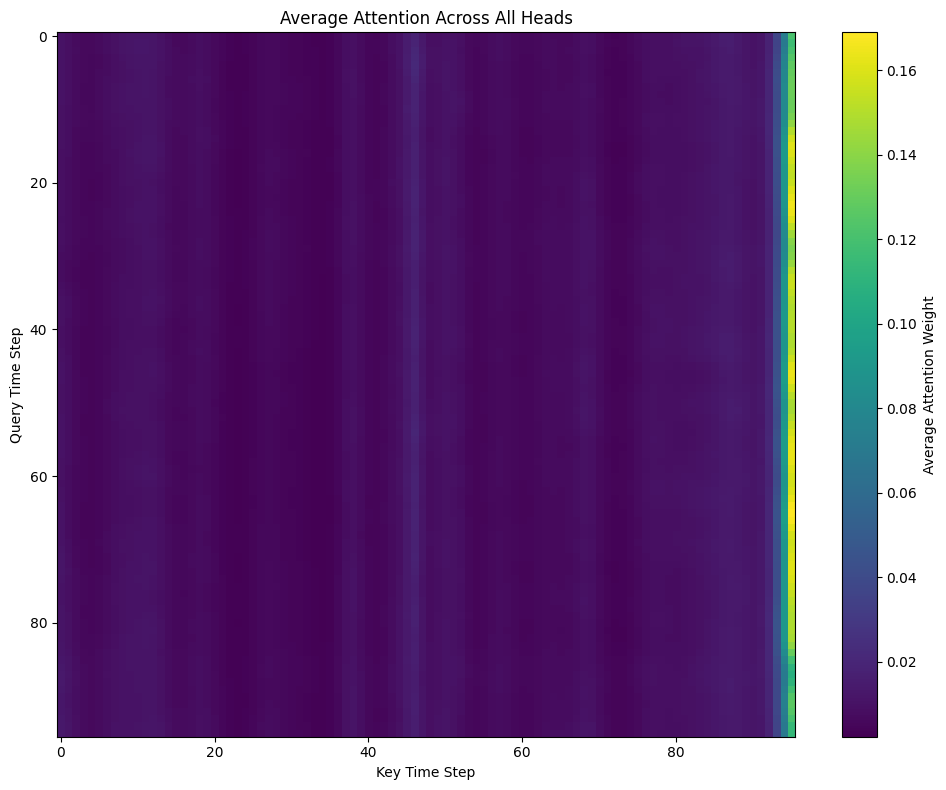

In [33]:
# Average across all attention heads
avg_attention = (
    attention_weights
    .mean(dim=(0,1))
    .cpu()
    .numpy()
)

print("Average Attention Shape:", avg_attention.shape)

plt.figure(figsize=(10, 8))

plt.imshow(
    avg_attention,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Average Attention Weight")

plt.title(
    "Average Attention Across All Heads"
)

plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")

plt.tight_layout()
plt.show()


## Step 4: Most Important Historical Timesteps

Top 10 Most Important Timesteps
Rank 1: Timestep 95 (Importance = 0.1469)
Rank 2: Timestep 94 (Importance = 0.0861)
Rank 3: Timestep 93 (Importance = 0.0414)
Rank 4: Timestep 92 (Importance = 0.0196)
Rank 5: Timestep 46 (Importance = 0.0173)
Rank 6: Timestep 87 (Importance = 0.0141)
Rank 7: Timestep 45 (Importance = 0.0138)
Rank 8: Timestep 86 (Importance = 0.0136)
Rank 9: Timestep 88 (Importance = 0.0132)
Rank 10: Timestep 91 (Importance = 0.0124)


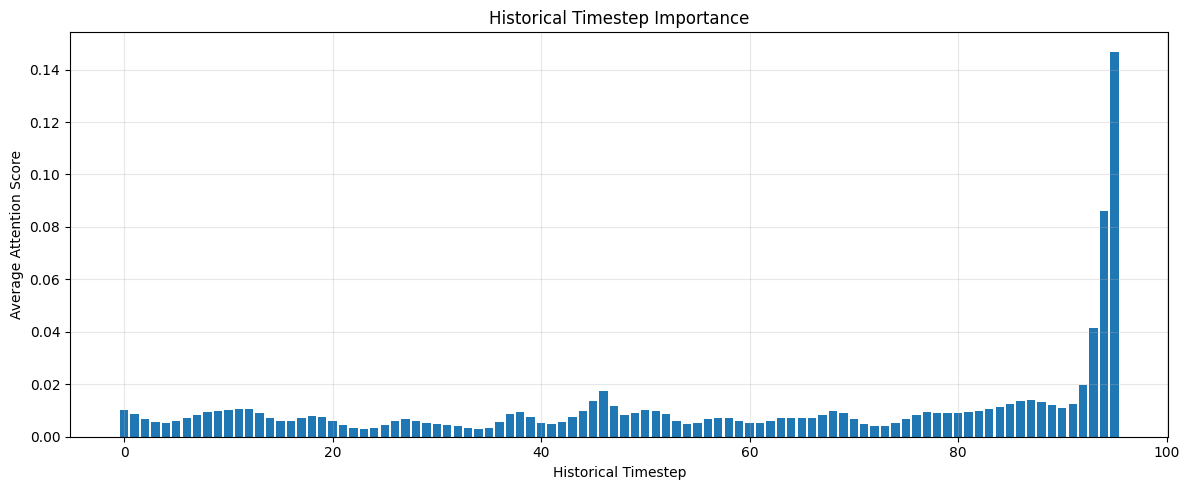

In [34]:
# Average attention over all query positions
importance_scores = avg_attention.mean(axis=0)

# Top 10 most important timesteps
top_k = 10

top_indices = np.argsort(importance_scores)[-top_k:][::-1]

print("Top 10 Most Important Timesteps")

for rank, idx in enumerate(top_indices, start=1):
    print(
        f"Rank {rank}: "
        f"Timestep {idx} "
        f"(Importance = {importance_scores[idx]:.4f})"
    )

# Visualization
plt.figure(figsize=(12,5))

plt.bar(
    range(len(importance_scores)),
    importance_scores
)

plt.title(
    "Historical Timestep Importance"
)

plt.xlabel("Historical Timestep")
plt.ylabel("Average Attention Score")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Step 5: Attention Head Comparison

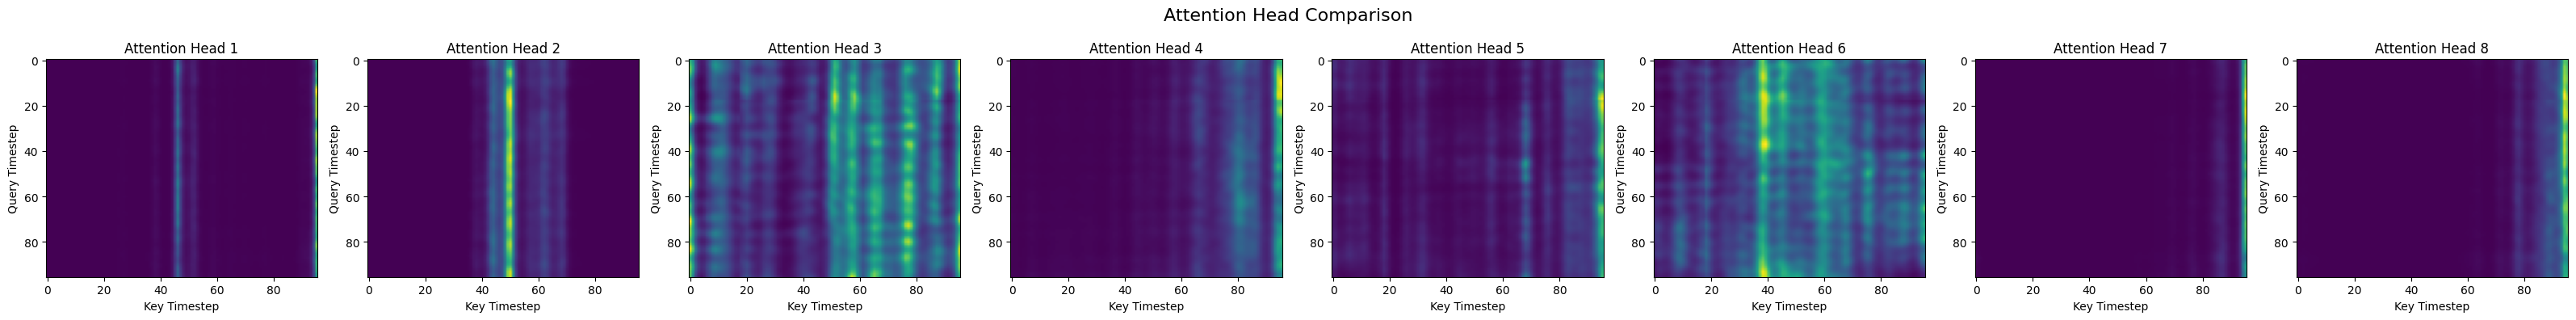

In [35]:
import matplotlib.pyplot as plt
import math

sample_attention = attention_weights[0]
num_heads = sample_attention.shape[0]
num_cols = min(NHEAD, num_heads)
num_rows = math.ceil(num_heads / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(4 * num_cols, 4 * num_rows)
)

axes = np.atleast_1d(axes).flat

for head_idx, ax in enumerate(axes):

    if head_idx >= num_heads:
        ax.axis("off")
        continue

    head_attention = (
        sample_attention[head_idx]
        .cpu()
        .numpy()
    )

    im = ax.imshow(
        head_attention,
        aspect="auto",
        cmap="viridis"
    )

    ax.set_title(
        f"Attention Head {head_idx + 1}"
    )

    ax.set_xlabel("Key Timestep")
    ax.set_ylabel("Query Timestep")

plt.suptitle(
    "Attention Head Comparison",
    fontsize=16
)

plt.tight_layout()

plt.show()


## Technique 2: Feature Ablation Analysis


## Step 1: Baseline Performance

In [36]:
baseline_rmse = rmse
baseline_mae = mae

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE :", baseline_mae)


Baseline RMSE: 145.52744105957805
Baseline MAE : 60.6229458915241


# Step 2: Single Feature Ablation Verification

In [37]:
feature_to_test = ABLATION_FEATURE

feature_idx = feature_columns.index(
    feature_to_test
)

predictions_ablation = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.clone()

        # Remove selected feature
        X_batch[:, :, feature_idx] = 0

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions_ablation.extend(
            outputs.cpu().numpy()
        )

predictions_ablation = np.array(
    predictions_ablation
)

rmse_ablation = np.sqrt(
    mean_squared_error(
        actual_original,
        inverse_target_scale(predictions_ablation)
    )
)

mae_ablation = mean_absolute_error(
    actual_original,
    inverse_target_scale(predictions_ablation)
)

print("\nFeature Removed:", feature_to_test)

print("Baseline RMSE :", baseline_rmse)
print("New RMSE      :", rmse_ablation)

print(
    "RMSE Increase :",
    rmse_ablation - baseline_rmse
)

print("\nBaseline MAE :", baseline_mae)
print("New MAE      :", mae_ablation)



Feature Removed: scd41_co2
Baseline RMSE : 145.52744105957805
New RMSE      : 185.74430544035744
RMSE Increase : 40.216864380779384

Baseline MAE : 60.6229458915241
New MAE      : 118.39327683195626


## Step 3: Multi-Feature Ablation Analysis

In [38]:
ablation_results = []

baseline_rmse = rmse
baseline_mae = mae

model.eval()

for feature_to_test in ABLATION_FEATURES:

    print(f"\nTesting Feature: {feature_to_test}")

    feature_idx = feature_columns.index(
        feature_to_test
    )

    predictions_ablation = []

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.clone()

            # Remove selected feature
            X_batch[:, :, feature_idx] = 0

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            predictions_ablation.extend(
                outputs.cpu().numpy()
            )

    predictions_ablation = np.array(
        predictions_ablation
    )

    rmse_ablation = np.sqrt(
        mean_squared_error(
            actual_original,
            inverse_target_scale(predictions_ablation),
        )
    )

    mae_ablation = mean_absolute_error(
        actual_original,
        inverse_target_scale(predictions_ablation)
    )

    rmse_increase = (
        rmse_ablation - baseline_rmse
    )

    mae_increase = (
        mae_ablation - baseline_mae
    )

    ablation_results.append([
        feature_to_test,
        rmse_ablation,
        mae_ablation,
        rmse_increase,
        mae_increase
    ])

    print(
        f"RMSE Increase: {rmse_increase:.6f}"
    )

# Convert to DataFrame
ablation_df = pd.DataFrame(
    ablation_results,
    columns=[
        "Feature",
        "RMSE",
        "MAE",
        "RMSE Increase",
        "MAE Increase"
    ]
)

# Sort by importance
ablation_df = (
    ablation_df
    .sort_values(
        by="RMSE Increase",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add ranking
ablation_df.index += 1

print("\nFeature Importance Ranking\n")
print(ablation_df)



Testing Feature: ens160_aqi
RMSE Increase: 15.047369

Testing Feature: ens160_tvoc
RMSE Increase: 0.484523

Testing Feature: bme688_gas_resistance
RMSE Increase: -5.211842

Testing Feature: bme688_pressure
RMSE Increase: -11.388509

Testing Feature: scd41_temperature
RMSE Increase: 47.533543

Testing Feature: scd41_humidity
RMSE Increase: 34.035071

Testing Feature: scd41_co2
RMSE Increase: 40.216864

Feature Importance Ranking

                 Feature        RMSE         MAE  RMSE Increase  MAE Increase
1      scd41_temperature  193.060984   81.597741      47.533543     20.974795
2              scd41_co2  185.744305  118.393277      40.216864     57.770331
3         scd41_humidity  179.562512   86.934023      34.035071     26.311077
4             ens160_aqi  160.574810   63.543938      15.047369      2.920992
5            ens160_tvoc  146.011964   60.729434       0.484523      0.106488
6  bme688_gas_resistance  140.315599   67.222369      -5.211842      6.599423
7        bme688_pres

## step 4: Feature Importance Visualization

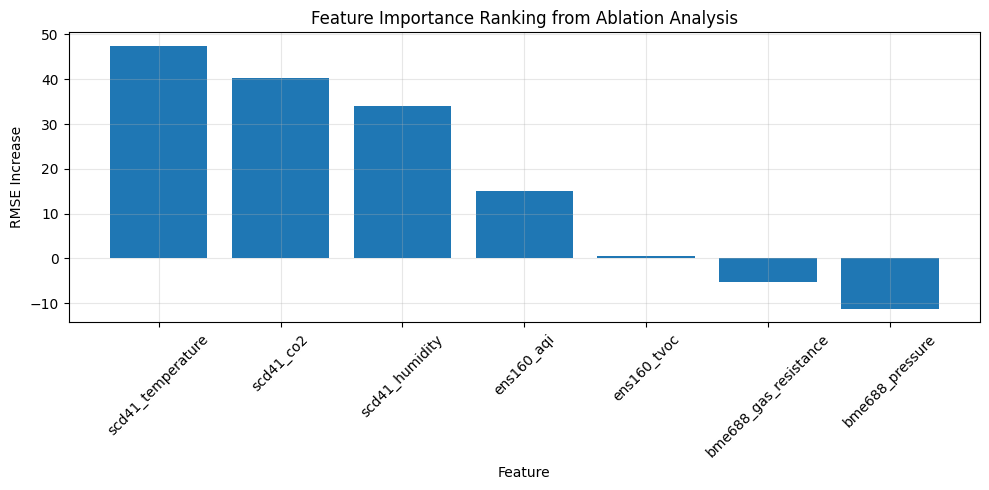

In [39]:
plt.figure(figsize=(10,5))

plt.bar(
    ablation_df["Feature"],
    ablation_df["RMSE Increase"]
)

plt.title(
    "Feature Importance Ranking from Ablation Analysis"
)

plt.xlabel("Feature")
plt.ylabel("RMSE Increase")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Uncertainty Quantification

## Technique 1: Monte Carlo Dropout

## Step 1:Dropout Layer Verification

In [40]:
print(model)

dropout_count = 0

for name, module in model.named_modules():

    if isinstance(module, nn.Dropout):

        dropout_count += 1

        print(
            f"Dropout Layer {dropout_count}:",
            name
        )

print(
    "\nTotal Dropout Layers:",
    dropout_count
)


TransformerModel(
  (input_projection): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (local_conv): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), groups=128)
    (1): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=384, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=384, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
 

## Step 2: Generate Monte Carlo Predictions

In [41]:
# Get one sample from test set

X_batch, y_batch = next(iter(test_loader))

sample = X_batch[:1].to(device)

mc_predictions = []

# Keep dropout active
model.train()

with torch.no_grad():

    for i in range(MC_DROPOUT_RUNS):

        prediction = model(sample)

        mc_predictions.append(
            prediction.cpu().numpy()
        )

mc_predictions = np.array(
    mc_predictions
)

print(
    "MC Prediction Shape:"
)

print(
    mc_predictions.shape
)

print(
    "\nFirst Prediction:"
)

print(
    mc_predictions[0]
)

if MC_DROPOUT_RUNS > 1:

    print(
        "\nSecond Prediction:"
    )

    print(
        mc_predictions[1]
    )


MC Prediction Shape:
(30, 1, 24)

First Prediction:
[[0.06314535 0.03257644 0.05347279 0.02469499 0.03856346 0.06122125
  0.04038328 0.05799271 0.04108762 0.04409094 0.04779773 0.03986179
  0.04076887 0.04661079 0.05761582 0.02874568 0.04879923 0.04300437
  0.0358412  0.03595129 0.03842248 0.04512344 0.04150623 0.05417984]]

Second Prediction:
[[0.05458028 0.05853891 0.05816197 0.03416836 0.04539483 0.04588444
  0.05021481 0.04121922 0.04297322 0.03546023 0.03413191 0.05216939
  0.03992077 0.05031442 0.03153102 0.0403866  0.03466144 0.05153858
  0.04479054 0.05077123 0.03734437 0.03023432 0.02278094 0.06157586]]


## Step 3: Compute Confidence Intervals

In [42]:
# Mean forecast

mean_prediction = np.mean(
    mc_predictions,
    axis=0
)

# Forecast uncertainty

std_prediction = np.std(
    mc_predictions,
    axis=0
)

# 95% Confidence Interval

lower_bound = (
    mean_prediction
    - 1.96 * std_prediction
)

upper_bound = (
    mean_prediction
    + 1.96 * std_prediction
)

print("Mean Prediction:\n")
print(mean_prediction)

print("\nStandard Deviation:\n")
print(std_prediction)

print("\nLower Bound:\n")
print(lower_bound)

print("\nUpper Bound:\n")
print(upper_bound)


Mean Prediction:

[[0.05284586 0.05245161 0.05297218 0.04521374 0.04228869 0.04591014
  0.04632961 0.04604965 0.04680258 0.04730771 0.04264676 0.0425486
  0.03981739 0.04373849 0.04281913 0.04154243 0.04063117 0.03937561
  0.03792258 0.03894939 0.03520181 0.03787146 0.03482895 0.03558572]]

Standard Deviation:

[[0.00706558 0.00897051 0.0080762  0.00952013 0.00591349 0.00601842
  0.0096425  0.00720096 0.00832677 0.00959328 0.00749954 0.00780694
  0.00899998 0.0085494  0.01033703 0.00645216 0.00751586 0.00887766
  0.00794384 0.00898765 0.00742014 0.00868733 0.00899998 0.00921031]]

Lower Bound:

[[0.03899733 0.0348694  0.03714282 0.02655429 0.03069825 0.03411404
  0.02743031 0.03193577 0.0304821  0.02850488 0.02794767 0.027247
  0.02217742 0.02698168 0.02255854 0.02889619 0.02590008 0.02197539
  0.02235264 0.0213336  0.02065833 0.02084429 0.01718899 0.01753351]]

Upper Bound:

[[0.0666944  0.07003383 0.06880154 0.06387319 0.05387912 0.05770624
  0.06522891 0.06016354 0.06312306 0.066110

## Step 4: Visualize Uncertainty

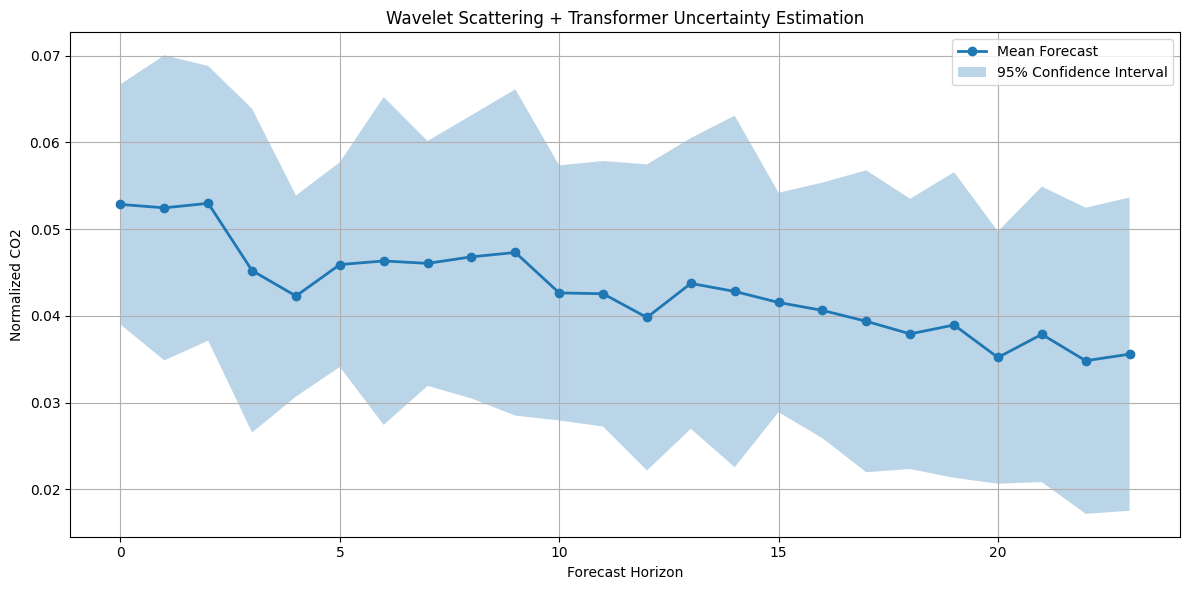

In [43]:
plt.figure(figsize=(12,6))

time_steps = np.arange(
    mean_prediction.shape[1]
)

plt.plot(
    time_steps,
    mean_prediction[0],
    marker="o",
    linewidth=2,
    label="Mean Forecast"
)

plt.fill_between(
    time_steps,
    lower_bound[0],
    upper_bound[0],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title(
    "Wavelet Scattering + Transformer Uncertainty Estimation"
)

plt.xlabel(
    "Forecast Horizon"
)

plt.ylabel(
    f"Normalized {target_label}"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


## Uncertainty Summary Table

In [44]:
uncertainty_df = pd.DataFrame({

    "Forecast Horizon": np.arange(
        1,
        OUTPUT_LENGTH + 1
    ),

    "Mean Prediction":
        mean_prediction[0],

    "Std Dev":
        std_prediction[0],

    "Lower Bound":
        lower_bound[0],

    "Upper Bound":
        upper_bound[0]
})

uncertainty_df


,Forecast Horizon,Mean Prediction,Std Dev,Lower Bound,Upper Bound
0,1,0.052846,0.007066,0.038997,0.066694
1,2,0.052452,0.008971,0.034869,0.070034
2,3,0.052972,0.008076,0.037143,0.068802
3,4,0.045214,0.009520,0.026554,0.063873
4,5,0.042289,0.005913,0.030698,0.053879
5,6,0.045910,0.006018,0.034114,0.057706
6,7,0.046330,0.009642,0.027430,0.065229
7,8,0.046050,0.007201,0.031936,0.060164
8,9,0.046803,0.008327,0.030482,0.063123
9,10,0.047308,0.009593,0.028505,0.066111


## Technique 2: Forecast Horizon Error Analysis

## step 1: Compute Horizon RMSE

In [45]:
horizon_rmse = []

for horizon in range(OUTPUT_LENGTH):
    rmse_h = np.sqrt(
        mean_squared_error(
            actual_original[:, horizon],
            predictions_original[:, horizon],
        )
    )
    horizon_rmse.append(rmse_h)

horizon_rmse


[np.float64(60.198122037549034),
 np.float64(69.47983322548254),
 np.float64(81.3394674811579),
 np.float64(95.48233513076677),
 np.float64(112.08879686038233),
 np.float64(122.57533966277343),
 np.float64(127.88676573983481),
 np.float64(134.55611454298025),
 np.float64(141.25132244708809),
 np.float64(145.49948593706475),
 np.float64(148.00251049043527),
 np.float64(149.63232710588412),
 np.float64(151.7906248035601),
 np.float64(153.9911454468707),
 np.float64(156.19242368605597),
 np.float64(158.77189997078858),
 np.float64(163.21021247328648),
 np.float64(167.91927589769406),
 np.float64(169.922395921455),
 np.float64(171.77020323468759),
 np.float64(175.5519334505756),
 np.float64(178.38819603256525),
 np.float64(179.10605780360174),
 np.float64(179.82401430107925)]

## step 2: Create Table

In [46]:
horizon_df = pd.DataFrame({

    "Forecast Horizon":
        np.arange(
            1,
            OUTPUT_LENGTH + 1
        ),

    "RMSE":
        horizon_rmse
})

horizon_df


,Forecast Horizon,RMSE
0,1,60.198122
1,2,69.479833
2,3,81.339467
3,4,95.482335
4,5,112.088797
5,6,122.575340
6,7,127.886766
7,8,134.556115
8,9,141.251322
9,10,145.499486


## step 3: Visualization

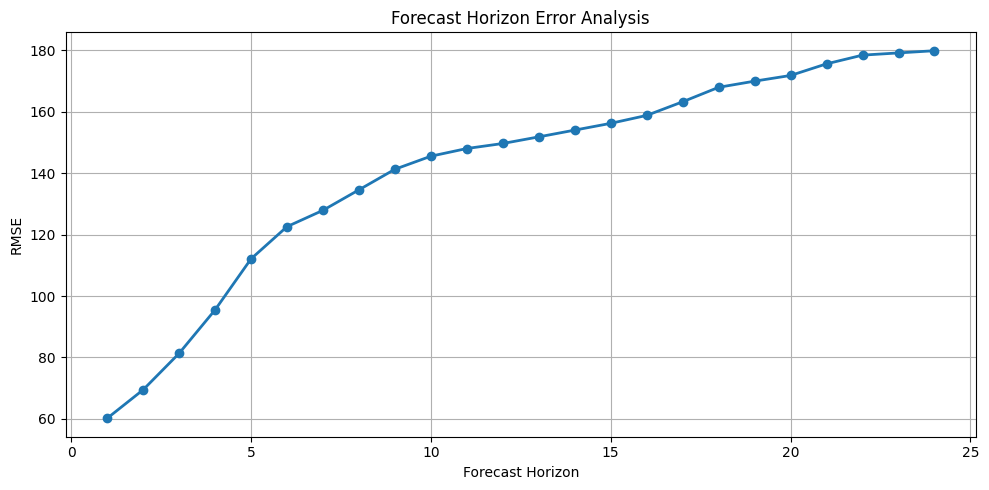

In [47]:
plt.figure(figsize=(10,5))

plt.plot(
    horizon_df["Forecast Horizon"],
    horizon_df["RMSE"],
    marker="o",
    linewidth=2
)

plt.title(
    "Forecast Horizon Error Analysis"
)

plt.xlabel(
    "Forecast Horizon"
)

plt.ylabel(
    "RMSE"
)

plt.grid(True)

plt.tight_layout()

plt.show()
